# Peptide backbone sampling — per-residue Ramachandran of the RFD1 de-novo 10-mers

RFdiffusion is a generative model, not a Boltzmann sampler — but the **spread of backbone dihedrals it
draws at each peptide position**, pooled over many independent designs, is a (crude, unweighted) proxy
for the conformational space it explores. Here we extract the peptide φ/ψ of every de-novo 10-mer
(OLD `grind`/`ladder`/`promising` + NEW `rfd_denovo30`) and plot per-residue Ramachandran clouds,
**aggregated per (source, pid, context, conditioning) group**, with the two native crystal peptides
(GIG/6AM5 ★, DRG/6AMU ▲) overlaid as reference.

*Columns = peptide interior residues **P2–P9** — the 8 positions with a defined (φ,ψ) pair. A 10-mer's
two termini each lack one backbone dihedral (P1 has no φ, P10 has no ψ), so there are 8, not 10, panels.*

In [1]:
import os, sys, glob, warnings; warnings.filterwarnings("ignore")
sys.path.insert(0, "/home/ubuntu/if-mhc/py")
from collections import OrderedDict
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import score_denovo_designs as SD          # reuse ROOT, AA, motif consts, parse_meta, gather, dir defaults
plt.rcParams.update({"figure.dpi": 110, "font.size": 8})
ROOT = SD.ROOT

def _dihedral(p0, p1, p2, p3):
    b1 = p2 - p1; b1 = b1 / (np.linalg.norm(b1) + 1e-9)
    v = (p0 - p1) - np.dot(p0 - p1, b1) * b1
    w = (p3 - p2) - np.dot(p3 - p2, b1) * b1
    return np.degrees(np.arctan2(np.dot(np.cross(b1, v), w), np.dot(v, w)))

def pep_residues(path):
    '''ordered peptide-chain residues [(resname,{N,CA,C})]; peptide = the 8-12 res chain that is not
       MHC / b2m / TCR (verified by sequence motifs).'''
    ch = OrderedDict()
    for l in open(path):
        if l.startswith("ATOM") and l[12:16].strip() in ("N", "CA", "C"):
            c = l[21]; rk = l[22:27]
            ch.setdefault(c, OrderedDict()).setdefault(rk, {"resname": l[17:20].strip()})
            ch[c][rk][l[12:16].strip()] = np.array([float(l[30:38]), float(l[38:46]), float(l[46:54])])
    for c, resd in ch.items():
        res = list(resd.values())
        seq = "".join(SD.AA.get(r["resname"], "x") for r in res)
        if 8 <= len(res) <= 12 and SD.B2M_MOTIF not in seq and not SD._has_tcr(seq) and SD.MHC_MOTIF not in seq:
            return res
    return None

def phipsi(res):
    '''per-residue (pos1based, phi, psi); both defined only for interior residues.'''
    out = []
    L = len(res)
    for i in range(L):
        r = res[i]
        if not all(a in r for a in ("N", "CA", "C")): continue
        phi = psi = None
        if i > 0 and "C" in res[i - 1]:
            phi = _dihedral(res[i - 1]["C"], r["N"], r["CA"], r["C"])
        if i < L - 1 and "N" in res[i + 1]:
            psi = _dihedral(r["N"], r["CA"], r["C"], res[i + 1]["N"])
        if phi is not None and psi is not None:
            out.append((i + 1, phi, psi))
    return out

# gather all de-novo designs (old + new)
dirs = [f"{ROOT}/outputs/{x}/pdb" for x in ("grind", "ladder", "promising")] + [f"{ROOT}/outputs/rfd_denovo30/pdb"]
dirs = [d for d in dirs if os.path.isdir(d)]
files = SD.gather(dirs)
rows = []
for f in files:
    res = pep_residues(f)
    if not res or len(res) != 10: continue
    meta = SD.parse_meta(f)
    for pos, phi, psi in phipsi(res):
        rows.append(dict(**meta, pos=pos, phi=phi, psi=psi, file=os.path.basename(f)))
D = pd.DataFrame(rows)
print("designs with peptide backbone:", D.file.nunique(), "| phi/psi points:", len(D),
      "| residue positions:", sorted(D.pos.unique()))
D.to_csv(f"{ROOT}/outputs/denovo_scores/peptide_phipsi.csv", index=False)

designs with peptide backbone: 997 | phi/psi points: 7976 | residue positions: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


In [2]:
# native reference peptides (crystal chain C) -> phi/psi per position
from Bio.PDB import PDBParser
_p = PDBParser(QUIET=True)
def native_phipsi(pid):
    m = _p.get_structure(pid, f"{ROOT}/inputs/focus_6am/{pid}.pdb")[0]
    res = [{"resname": r.resname, **{a: r[a].coord.astype(float) for a in ("N","CA","C") if a in r}}
           for r in m["C"] if r.id[0] == " "]
    return {pos: (phi, psi) for pos, phi, psi in phipsi(res)}
NAT = {"6AM5": native_phipsi("6AM5"), "6AMU": native_phipsi("6AMU")}   # GIG, DRG
POSITIONS = sorted(D.pos.unique())
print("native GIG P-range:", sorted(NAT['6AM5']), "| columns:", POSITIONS)

def rama_ax(ax, sub, title="", star=None, tri=None):
    if len(sub):
        ax.scatter(sub.phi, sub.psi, s=6, alpha=0.35, color="#1f6fb2", edgecolor="none")
    if star is not None: ax.scatter(*star, marker="*", s=130, color="#e8000b", edgecolor="k", lw=0.4, zorder=5)  # GIG
    if tri  is not None: ax.scatter(*tri,  marker="^", s=70,  color="#f7b500", edgecolor="k", lw=0.4, zorder=5)  # DRG
    ax.axhline(0, lw=0.4, color="gray", alpha=0.5); ax.axvline(0, lw=0.4, color="gray", alpha=0.5)
    ax.set_xlim(-180, 180); ax.set_ylim(-180, 180); ax.set_xticks([-180,0,180]); ax.set_yticks([-180,0,180])
    ax.tick_params(labelsize=6)
    if title: ax.set_title(title, fontsize=7)

native GIG P-range: [2, 3, 4, 5, 6, 7, 8, 9] | columns: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


## 1 · Congregate — all de-novo designs pooled
The overall backbone-dihedral space RFd samples at each peptide position (★ = native GIG, ▲ = native DRG).

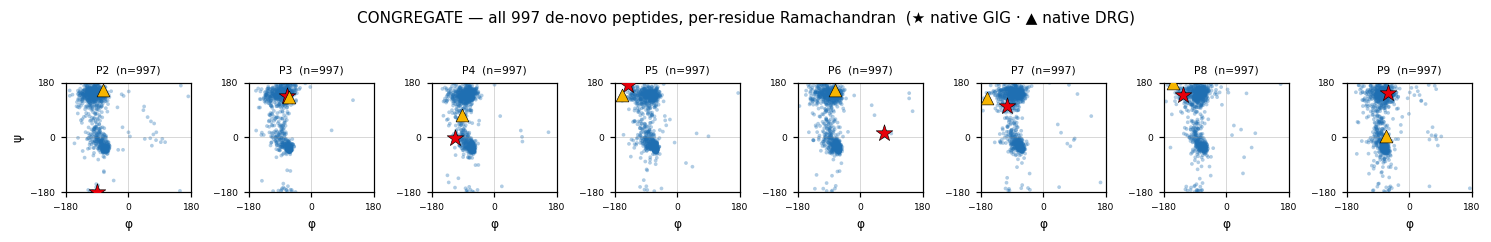

In [3]:
fig, axes = plt.subplots(1, len(POSITIONS), figsize=(1.7*len(POSITIONS), 2.0), squeeze=False)
for j, pos in enumerate(POSITIONS):
    ax = axes[0, j]
    rama_ax(ax, D[D.pos==pos], title=f"P{pos}  (n={D[D.pos==pos].file.nunique()})",
            star=NAT["6AM5"].get(pos), tri=NAT["6AMU"].get(pos))
    if j==0: ax.set_ylabel("ψ")
    ax.set_xlabel("φ")
fig.suptitle(f"CONGREGATE — all {D.file.nunique()} de-novo peptides, per-residue Ramachandran  "
             f"(★ native GIG · ▲ native DRG)", y=1.06, fontsize=10)
plt.tight_layout(); plt.savefig(f"{ROOT}/outputs/denovo_scores/rama_congregate.png", dpi=140, bbox_inches="tight"); plt.show()

## 2 · By crystal × context (pooled)
Does removing the TCR (noTCR) or switching template (6AM5/6AMU) shift the sampled backbone space?

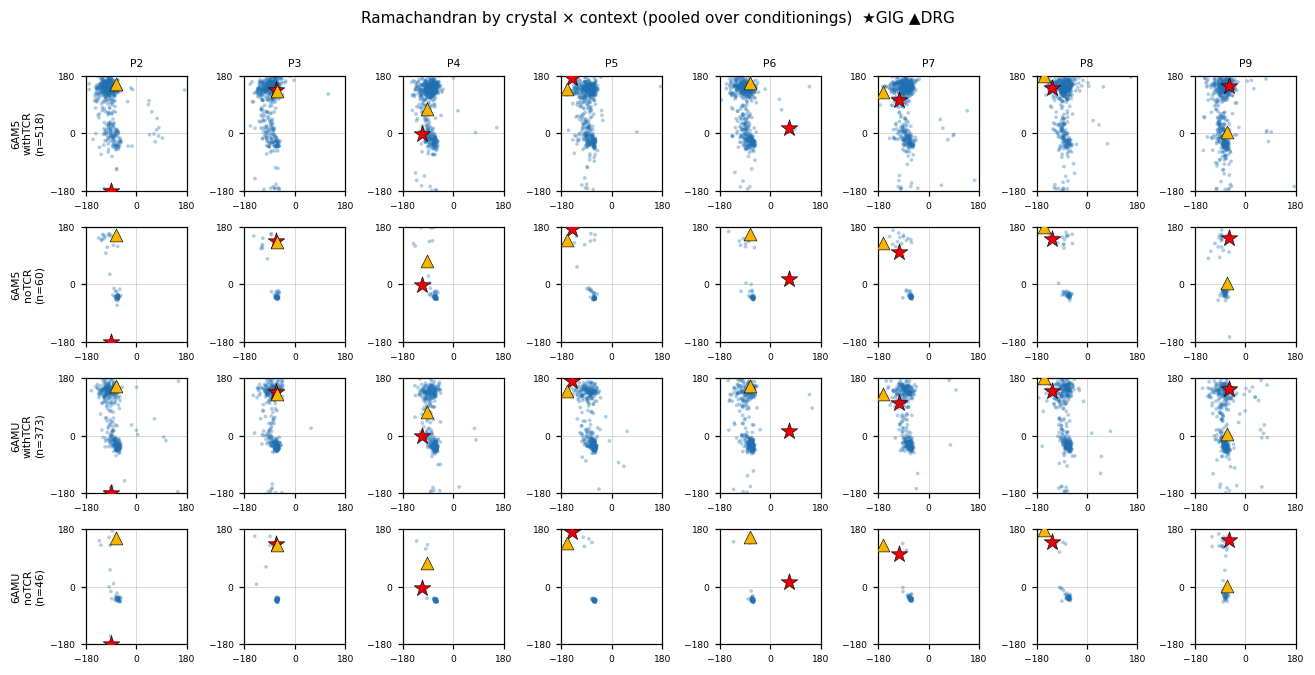

In [4]:
combos = [("6AM5","withTCR"),("6AM5","noTCR"),("6AMU","withTCR"),("6AMU","noTCR")]
fig, axes = plt.subplots(len(combos), len(POSITIONS), figsize=(1.5*len(POSITIONS), 1.5*len(combos)), squeeze=False)
for i,(pid,ctx) in enumerate(combos):
    sub_all = D[(D.pid==pid)&(D.context==ctx)]
    for j,pos in enumerate(POSITIONS):
        ax = axes[i,j]
        rama_ax(ax, sub_all[sub_all.pos==pos], star=NAT["6AM5"].get(pos), tri=NAT["6AMU"].get(pos))
        if i==0: ax.set_title(f"P{pos}", fontsize=7)
        if j==0: ax.set_ylabel(f"{pid}\n{ctx}\n(n={sub_all.file.nunique()})", fontsize=7)
fig.suptitle("Ramachandran by crystal × context (pooled over conditionings)  ★GIG ▲DRG", y=1.01, fontsize=10)
plt.tight_layout(); plt.savefig(f"{ROOT}/outputs/denovo_scores/rama_pid_context.png", dpi=140, bbox_inches="tight"); plt.show()

## 3 · Full per-group grid — rows = (source/pid/context/cond), columns = P2–P9
The requested view: one row per group, each cell aggregates that group's designs. One figure per source
(kept legible); saved to `outputs/denovo_scores/rama_<source>.png`.

saved /home/ubuntu/if-mhc/outputs/denovo_scores/rama_denovo30.png


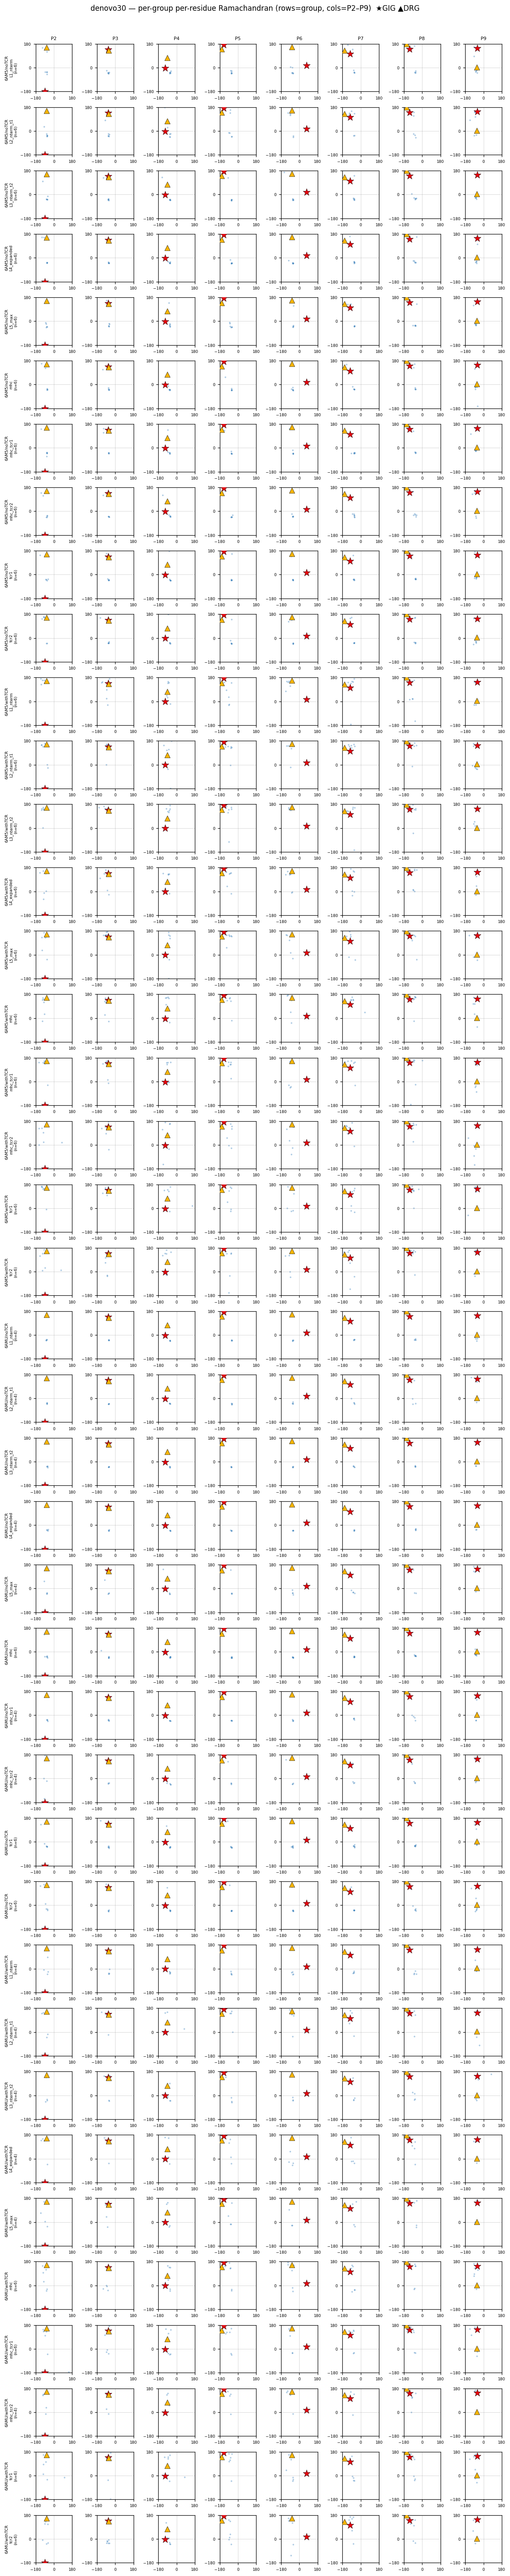

saved /home/ubuntu/if-mhc/outputs/denovo_scores/rama_promising.png


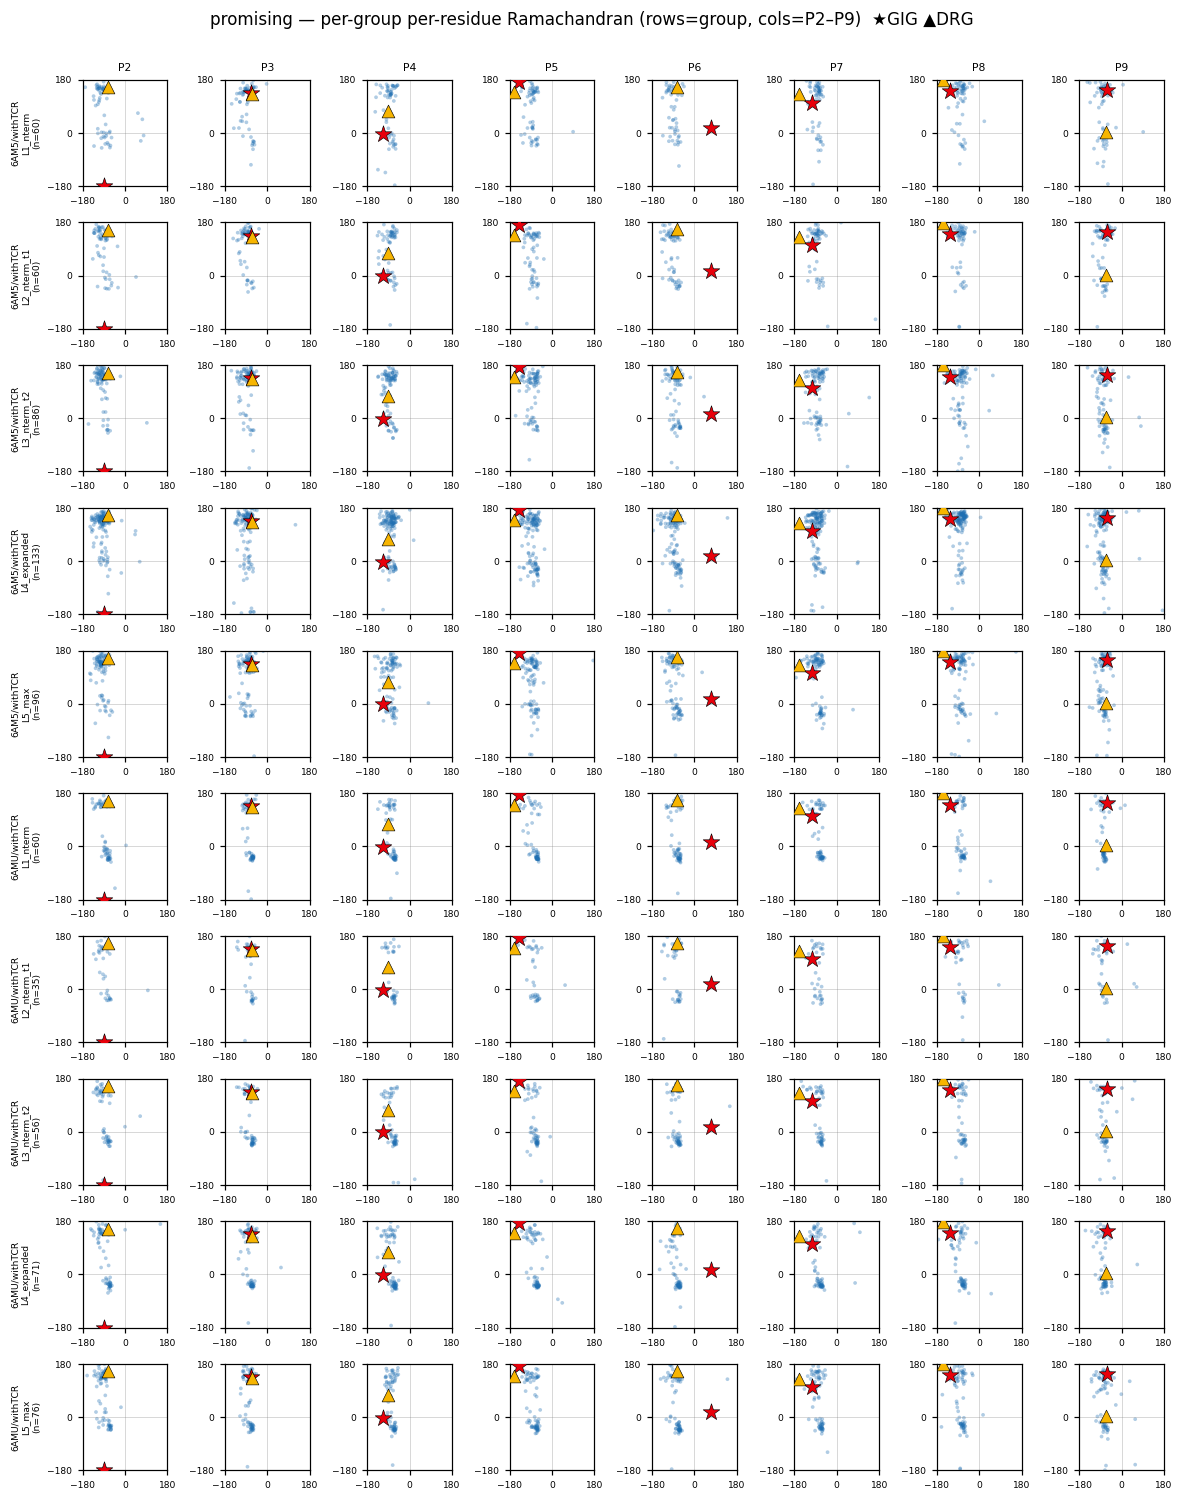

saved /home/ubuntu/if-mhc/outputs/denovo_scores/rama_grind.png


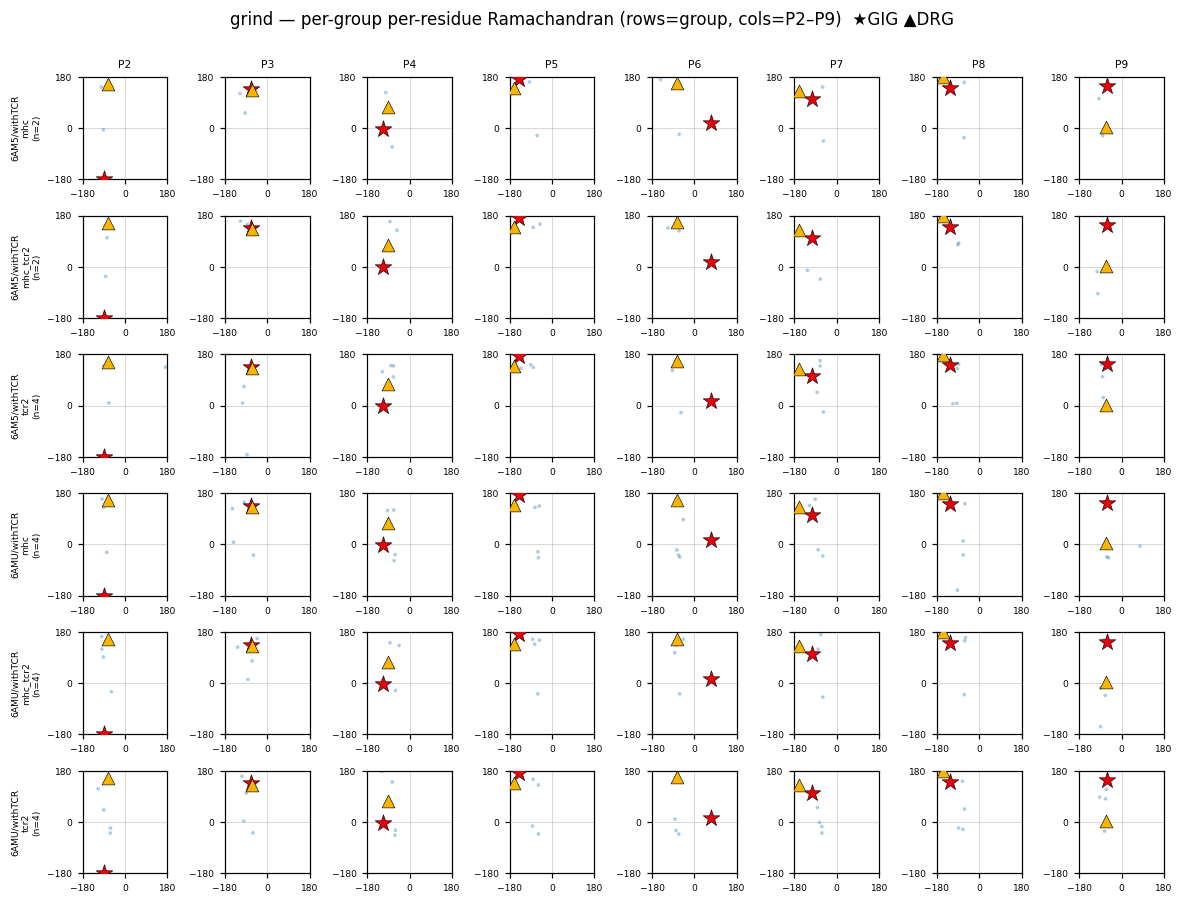

saved /home/ubuntu/if-mhc/outputs/denovo_scores/rama_ladder.png


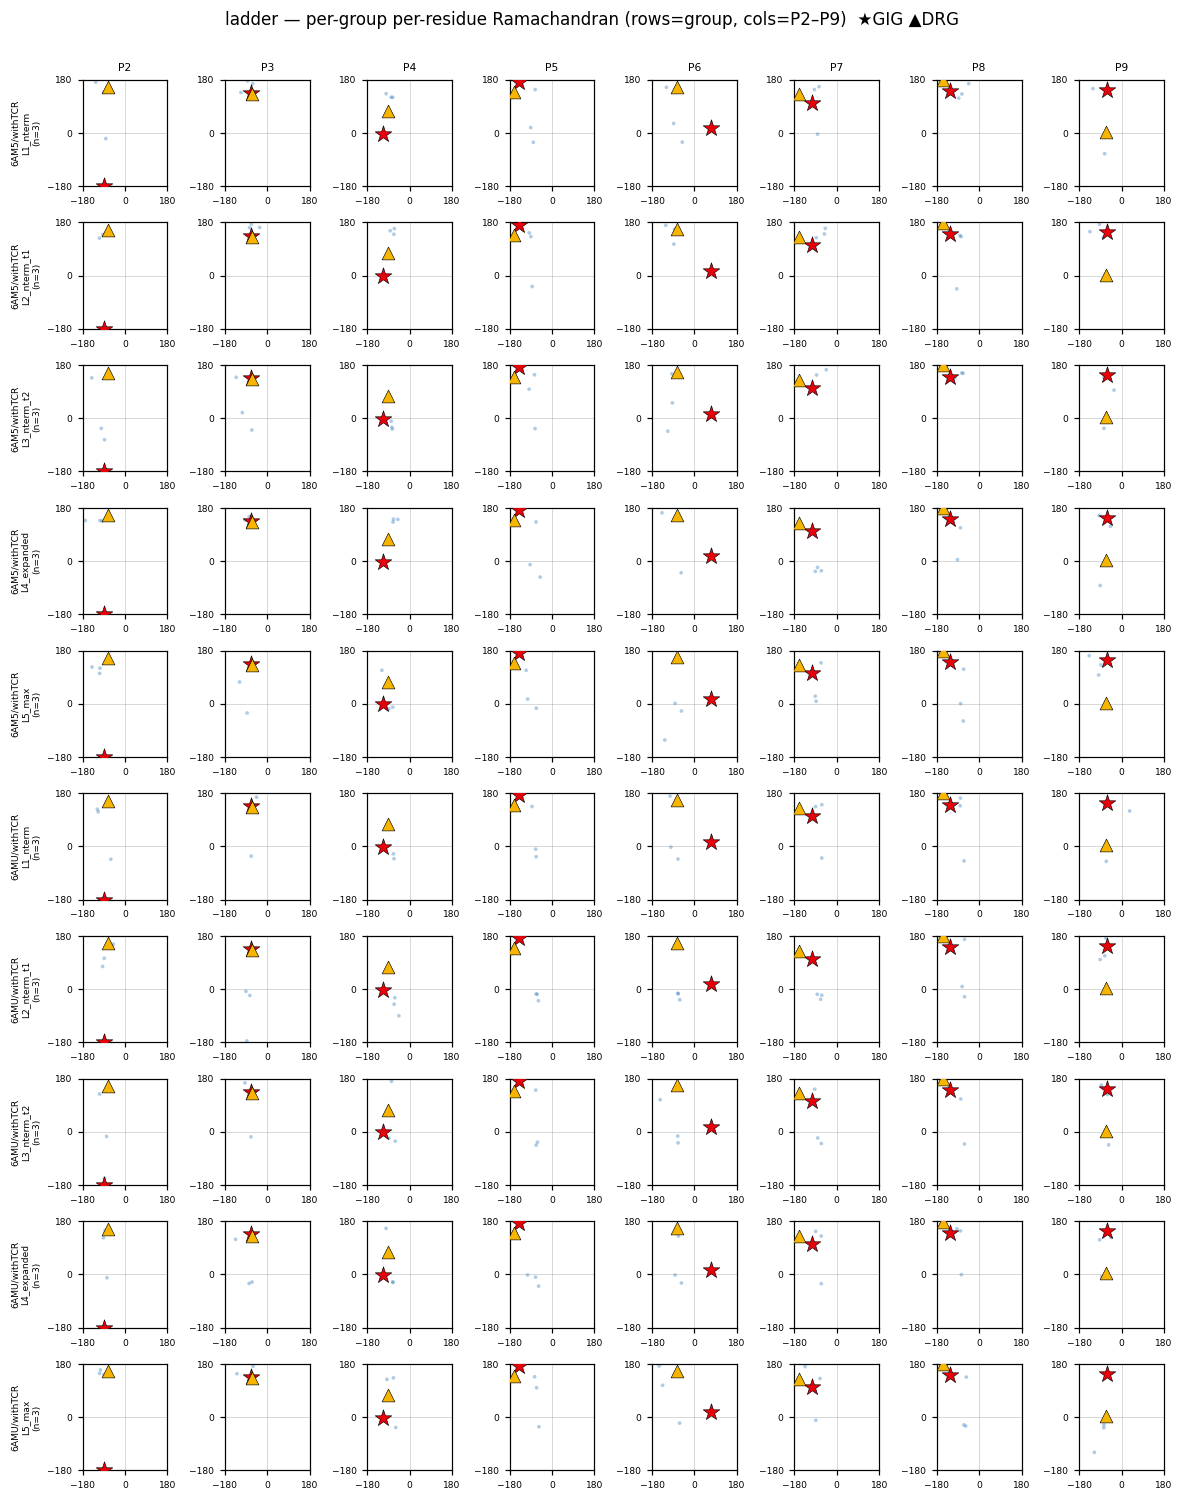

In [5]:
for source in ["denovo30","promising","grind","ladder"]:
    Ds = D[D.source==source]
    if not len(Ds): continue
    groups = (Ds.groupby(["pid","context","cond"]).file.nunique()
              .reset_index(name="n").sort_values(["pid","context","cond"]))
    R = len(groups)
    fig, axes = plt.subplots(R, len(POSITIONS), figsize=(1.35*len(POSITIONS), 1.35*R), squeeze=False)
    for i,(_,gr) in enumerate(groups.iterrows()):
        sub = Ds[(Ds.pid==gr.pid)&(Ds.context==gr.context)&(Ds.cond==gr.cond)]
        for j,pos in enumerate(POSITIONS):
            ax = axes[i,j]
            rama_ax(ax, sub[sub.pos==pos], star=NAT["6AM5"].get(pos), tri=NAT["6AMU"].get(pos))
            if i==0: ax.set_title(f"P{pos}", fontsize=7)
            if j==0: ax.set_ylabel(f"{gr.pid}/{gr.context}\n{gr.cond}\n(n={gr.n})", fontsize=6)
    fig.suptitle(f"{source} — per-group per-residue Ramachandran (rows=group, cols=P2–P9)  ★GIG ▲DRG",
                 y=1.005, fontsize=11)
    plt.tight_layout()
    out = f"{ROOT}/outputs/denovo_scores/rama_{source}.png"
    plt.savefig(out, dpi=120, bbox_inches="tight"); print("saved", out); plt.show()

## Reading the plots

- **Tight cluster near the native ★/▲** at a position = RFd reliably reproduces that residue's backbone
  (usually the anchor/framework positions); a **diffuse smear** = RFd is sampling many backbone states
  there (the flexible / de-novo-uncertain positions).
- Because RFd draws are **not Boltzmann-weighted**, cloud density is *not* a free energy — but a bimodal
  or split cloud at the C-terminal anchor positions is where a register flip would have to live, so it is
  the place to look for any hint of the alternate (non-cognate ▲ vs ★) basin being sampled.
- Compare **withTCR vs noTCR** rows (§2/§3): if the clouds are indistinguishable, the TCR context is not
  reshaping the peptide backbone RFd draws — consistent with the register being peptide-intrinsic.

Data: `outputs/denovo_scores/peptide_phipsi.csv` · figures `rama_congregate.png`, `rama_pid_context.png`,
`rama_<source>.png`.